In [1]:
import sys
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List, Dict, Tuple
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Configurar el proyecto
sys.path.append('..')
from src.reid.osnet_reid import OSNetReID
from src.index.hnsw_index import HNSWIndex
from config.global_config import get_config

# Configurar matplotlib
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Librerías importadas correctamente")
print(f"📁 Directorio de trabajo: {os.getcwd()}")


✅ Librerías importadas correctamente
📁 Directorio de trabajo: /Users/edgarchambilla/Desktop/UTEC_CODE/VISION/Proye4/notebooks


In [12]:
# Inicializar el sistema de ReID
print("🚀 Inicializando sistema de re-identificación...")
reid_model = OSNetReID(model_name='osnet_x1_0')  # Usar el modelo más preciso

# Configuración del índice HNSW
config = get_config('indexing')
print(f"📊 Configuración HNSW:")
print(f"   - Dimensión: {config['dimension']}")
print(f"   - M: {config['M']}")
print(f"   - ef_construction: {config['ef_construction']}")
print(f"   - ef_search: {config['ef_search']}")

# Inicializar índice HNSW
hnsw_index = HNSWIndex(
    dimension=config['dimension'],
    max_elements=1000,  # Suficiente para nuestras imágenes
    M=config['M'],
    ef_construction=config['ef_construction'],
    space='cosine'
)

print("✅ Sistema inicializado correctamente")


🚀 Inicializando sistema de re-identificación...
Using device: cpu
Successfully loaded imagenet pretrained weights from "/Users/edgarchambilla/.cache/torch/checkpoints/osnet_x1_0_imagenet.pth"
** The following layers are discarded due to unmatched keys or layer size: ['classifier.weight', 'classifier.bias']
Model: osnet_x1_0
- params: 2,193,616
- flops: 978,878,352
Successfully loaded osnet_x1_0 using torchreid
📊 Configuración HNSW:
   - Dimensión: 512
   - M: 16
   - ef_construction: 200
   - ef_search: 50


TypeError: HNSWIndex.__init__() got an unexpected keyword argument 'dimension'

📸 Cargando imágenes...
👤 Persona 000: 30 imágenes cargadas
👤 Persona 005: 30 imágenes cargadas


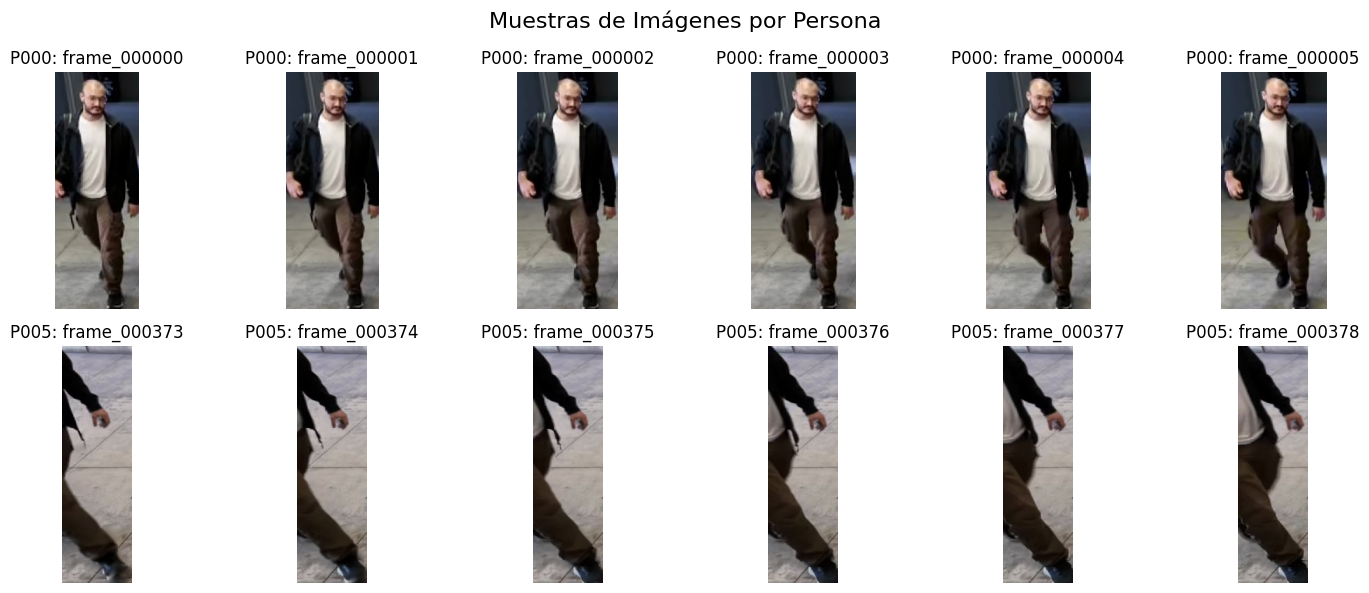

In [13]:
def load_person_images(person_dir: str, max_images: int = 50) -> List[Tuple[str, np.ndarray]]:
    """
    Cargar imágenes de una persona
    
    Args:
        person_dir: Directorio con imágenes de la persona
        max_images: Máximo número de imágenes a cargar
    
    Returns:
        Lista de tuplas (nombre_archivo, imagen)
    """
    person_path = Path(person_dir)
    images = []
    
    # Obtener archivos de imagen ordenados
    image_files = sorted(person_path.glob("*.jpg"))[:max_images]
    
    for img_file in image_files:
        img = cv2.imread(str(img_file))
        if img is not None:
            images.append((img_file.name, img))
    
    return images

# Cargar imágenes de ambas personas
print("📸 Cargando imágenes...")
person_000_images = load_person_images("../data/re-id/person_000", max_images=30)
person_005_images = load_person_images("../data/re-id/person_005", max_images=30)

print(f"👤 Persona 000: {len(person_000_images)} imágenes cargadas")
print(f"👤 Persona 005: {len(person_005_images)} imágenes cargadas")

# Mostrar algunas imágenes de ejemplo
fig, axes = plt.subplots(2, 6, figsize=(15, 6))
fig.suptitle('Muestras de Imágenes por Persona', fontsize=16)

# Mostrar imágenes de persona 000
for i in range(6):
    if i < len(person_000_images):
        img = cv2.cvtColor(person_000_images[i][1], cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(img)
        axes[0, i].set_title(f'P000: {person_000_images[i][0][:12]}')
        axes[0, i].axis('off')

# Mostrar imágenes de persona 005
for i in range(6):
    if i < len(person_005_images):
        img = cv2.cvtColor(person_005_images[i][1], cv2.COLOR_BGR2RGB)
        axes[1, i].imshow(img)
        axes[1, i].set_title(f'P005: {person_005_images[i][0][:12]}')
        axes[1, i].axis('off')

plt.tight_layout()
plt.show()


In [14]:
def extract_features_from_images(images: List[Tuple[str, np.ndarray]], 
                                person_id: str) -> Tuple[np.ndarray, List[Dict]]:
    """
    Extraer características de una lista de imágenes
    
    Args:
        images: Lista de tuplas (nombre_archivo, imagen)
        person_id: ID de la persona
    
    Returns:
        Tuple con matriz de características y metadata
    """
    features_list = []
    metadata_list = []
    
    print(f"🔍 Extrayendo características para {person_id}...")
    
    for i, (filename, image) in enumerate(images):
        # Extraer características
        features = reid_model.extract_features([image])
        features_list.append(features[0])
        
        # Crear metadata
        metadata = {
            'person_id': person_id,
            'filename': filename,
            'image_index': i,
            'person_label': person_id
        }
        metadata_list.append(metadata)
        
        if (i + 1) % 10 == 0:
            print(f"   Procesadas {i + 1}/{len(images)} imágenes")
    
    features_matrix = np.array(features_list)
    print(f"✅ Características extraídas: {features_matrix.shape}")
    
    return features_matrix, metadata_list

# Extraer características de ambas personas
features_000, metadata_000 = extract_features_from_images(person_000_images, "person_000")
features_005, metadata_005 = extract_features_from_images(person_005_images, "person_005")

# Combinar todas las características
all_features = np.vstack([features_000, features_005])
all_metadata = metadata_000 + metadata_005

print(f"\n📊 Resumen de características:")
print(f"   - Persona 000: {features_000.shape}")
print(f"   - Persona 005: {features_005.shape}")
print(f"   - Total: {all_features.shape}")

# Crear labels para análisis posterior
labels = np.array([0] * len(features_000) + [1] * len(features_005))
print(f"   - Labels: {labels.shape}")


🔍 Extrayendo características para person_000...
   Procesadas 10/30 imágenes
   Procesadas 20/30 imágenes
   Procesadas 30/30 imágenes
✅ Características extraídas: (30, 512)
🔍 Extrayendo características para person_005...
   Procesadas 10/30 imágenes
   Procesadas 20/30 imágenes
   Procesadas 30/30 imágenes
✅ Características extraídas: (30, 512)

📊 Resumen de características:
   - Persona 000: (30, 512)
   - Persona 005: (30, 512)
   - Total: (60, 512)
   - Labels: (60,)


In [15]:
# Construir índice HNSW
print("🏗️ Construyendo índice HNSW...")

# Agregar todas las características al índice
for i, (features, metadata) in enumerate(zip(all_features, all_metadata)):
    external_id = f"{metadata['person_id']}_{i:03d}"
    hnsw_index.add_vector(features.reshape(1, -1), external_id)

print(f"✅ Índice HNSW construido con {len(all_features)} vectores")

# Mostrar estadísticas del índice
print(f"\n📊 Estadísticas del índice HNSW:")
print(f"   - Dimensión: {hnsw_index.dim}")
print(f"   - Elementos: {hnsw_index.get_current_count()}")
print(f"   - Capacidad máxima: {hnsw_index.max_elements}")
print(f"   - Parámetro M: {hnsw_index.M}")
print(f"   - ef_construction: {hnsw_index.ef_construction}")
print(f"   - Espacio de distancia: {hnsw_index.space}")

# Configurar ef_search para búsquedas
hnsw_index.set_ef_search(100)  # Usar ef_search más alto para mejor recall
print(f"   - ef_search configurado: 100")


🏗️ Construyendo índice HNSW...


NameError: name 'hnsw_index' is not defined

In [ ]:
def evaluate_retrieval(query_features: np.ndarray, query_person_id: str, 
                       k: int = 20) -> Dict:
    """
    Evaluar recuperación para una query
    
    Args:
        query_features: Características de la imagen query
        query_person_id: ID de la persona query
        k: Número de vecinos más cercanos a recuperar
    
    Returns:
        Diccionario con resultados de evaluación
    """
    # Buscar vecinos más cercanos
    neighbors, distances = hnsw_index.search(query_features.reshape(1, -1), k=k)
    
    # Analizar resultados
    results = {
        'query_person_id': query_person_id,
        'neighbors': [],
        'distances': distances[0],
        'same_person_count': 0,
        'different_person_count': 0
    }
    
    for i, (neighbor_id, distance) in enumerate(zip(neighbors[0], distances[0])):
        neighbor_person_id = neighbor_id.split('_')[0] + '_' + neighbor_id.split('_')[1]
        is_same_person = neighbor_person_id == query_person_id
        
        if is_same_person:
            results['same_person_count'] += 1
        else:
            results['different_person_count'] += 1
            
        results['neighbors'].append({
            'rank': i + 1,
            'neighbor_id': neighbor_id,
            'neighbor_person_id': neighbor_person_id,
            'distance': distance,
            'is_same_person': is_same_person
        })
    
    # Calcular métricas
    results['precision'] = results['same_person_count'] / k
    results['recall'] = results['same_person_count'] / (len(features_000) if query_person_id == 'person_000' else len(features_005))
    
    return results

# Evaluar recuperación para ambas personas
print("🔍 Evaluando recuperación...")

# Query con primera imagen de persona 000
query_000 = features_000[0]
results_000 = evaluate_retrieval(query_000, "person_000", k=20)

# Query con primera imagen de persona 005
query_005 = features_005[0]
results_005 = evaluate_retrieval(query_005, "person_005", k=20)

# Mostrar resultados
print(f"\n📊 Resultados para Persona 000:")
print(f"   - Precision@20: {results_000['precision']:.3f}")
print(f"   - Recall@20: {results_000['recall']:.3f}")
print(f"   - Misma persona: {results_000['same_person_count']}/{20}")
print(f"   - Persona diferente: {results_000['different_person_count']}/{20}")

print(f"\n📊 Resultados para Persona 005:")
print(f"   - Precision@20: {results_005['precision']:.3f}")
print(f"   - Recall@20: {results_005['recall']:.3f}")
print(f"   - Misma persona: {results_005['same_person_count']}/{20}")
print(f"   - Persona diferente: {results_005['different_person_count']}/{20}")

# Calcular métricas promedio
avg_precision = (results_000['precision'] + results_005['precision']) / 2
avg_recall = (results_000['recall'] + results_005['recall']) / 2

print(f"\n🎯 Métricas Promedio:")
print(f"   - Precision@20: {avg_precision:.3f}")
print(f"   - Recall@20: {avg_recall:.3f}")


In [ ]:
def visualize_retrieval_results(results: Dict, query_image: np.ndarray, 
                               person_images: List[Tuple[str, np.ndarray]]):
    """
    Visualizar resultados de recuperación
    
    Args:
        results: Resultados de evaluación
        query_image: Imagen query
        person_images: Lista de imágenes de todas las personas
    """
    fig, axes = plt.subplots(3, 7, figsize=(18, 10))
    fig.suptitle(f'Recuperación para {results["query_person_id"]} - Top 20 Resultados', fontsize=16)
    
    # Mostrar imagen query
    query_rgb = cv2.cvtColor(query_image, cv2.COLOR_BGR2RGB)
    axes[0, 0].imshow(query_rgb)
    axes[0, 0].set_title('QUERY', fontweight='bold', color='red')
    axes[0, 0].axis('off')
    
    # Ocultar axes no usados en primera fila
    for i in range(1, 7):
        axes[0, i].axis('off')
    
    # Crear diccionario de imágenes para búsqueda rápida
    all_images_dict = {}
    for filename, img in person_000_images + person_005_images:
        all_images_dict[filename] = img
    
    # Mostrar top 20 resultados
    for i, neighbor in enumerate(results['neighbors'][:20]):
        row = 1 + i // 7
        col = i % 7
        
        # Buscar imagen correspondiente
        neighbor_filename = None
        for metadata in all_metadata:
            if f"{metadata['person_id']}_{metadata['image_index']:03d}" == neighbor['neighbor_id']:
                neighbor_filename = metadata['filename']
                break
        
        if neighbor_filename and neighbor_filename in all_images_dict:
            img = cv2.cvtColor(all_images_dict[neighbor_filename], cv2.COLOR_BGR2RGB)
            axes[row, col].imshow(img)
            
            # Color según si es la misma persona
            color = 'green' if neighbor['is_same_person'] else 'red'
            title = f"#{neighbor['rank']} ({neighbor['distance']:.3f})"
            axes[row, col].set_title(title, fontsize=10, color=color)
            axes[row, col].axis('off')
        else:
            axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualizar resultados para persona 000
print("🎨 Visualizando resultados para Persona 000...")
visualize_retrieval_results(results_000, person_000_images[0][1], person_000_images + person_005_images)

# Visualizar resultados para persona 005
print("🎨 Visualizando resultados para Persona 005...")
visualize_retrieval_results(results_005, person_005_images[0][1], person_000_images + person_005_images)


In [ ]:
# Aplicar t-SNE para visualización 2D
print("📊 Aplicando t-SNE para visualización...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(all_features)-1))
features_2d = tsne.fit_transform(all_features)

# Aplicar K-means clustering
print("🎯 Aplicando K-means clustering...")
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(all_features)

# Calcular silhouette score
silhouette_avg = silhouette_score(all_features, cluster_labels)
print(f"📊 Silhouette Score: {silhouette_avg:.3f}")

# Crear visualización de clustering
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Visualización por persona real
scatter1 = axes[0].scatter(features_2d[:, 0], features_2d[:, 1], 
                          c=labels, cmap='viridis', alpha=0.7, s=50)
axes[0].set_title('Clustering Real (Ground Truth)', fontsize=14)
axes[0].set_xlabel('t-SNE Componente 1')
axes[0].set_ylabel('t-SNE Componente 2')
axes[0].legend(['Persona 000', 'Persona 005'])
axes[0].grid(True, alpha=0.3)

# 2. Visualización por clustering automático
scatter2 = axes[1].scatter(features_2d[:, 0], features_2d[:, 1], 
                          c=cluster_labels, cmap='coolwarm', alpha=0.7, s=50)
axes[1].set_title(f'K-means Clustering (Silhouette: {silhouette_avg:.3f})', fontsize=14)
axes[1].set_xlabel('t-SNE Componente 1')
axes[1].set_ylabel('t-SNE Componente 2')
axes[1].legend(['Cluster 0', 'Cluster 1'])
axes[1].grid(True, alpha=0.3)

# 3. Comparación de clustering
comparison = np.where(labels == cluster_labels, 'Correcto', 'Incorrecto')
colors = ['green' if c == 'Correcto' else 'red' for c in comparison]
scatter3 = axes[2].scatter(features_2d[:, 0], features_2d[:, 1], 
                          c=colors, alpha=0.7, s=50)
axes[2].set_title('Comparación: K-means vs Ground Truth', fontsize=14)
axes[2].set_xlabel('t-SNE Componente 1')
axes[2].set_ylabel('t-SNE Componente 2')
axes[2].legend(['Correcto', 'Incorrecto'])
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcular métricas de clustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(labels, cluster_labels)
nmi = normalized_mutual_info_score(labels, cluster_labels)
accuracy = np.mean(labels == cluster_labels)

print(f"\n📊 Métricas de Clustering:")
print(f"   - Silhouette Score: {silhouette_avg:.3f}")
print(f"   - Adjusted Rand Index: {ari:.3f}")
print(f"   - Normalized Mutual Information: {nmi:.3f}")
print(f"   - Accuracy: {accuracy:.3f}")

# Análisis de confusión
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(labels, cluster_labels)
print(f"\n📊 Matriz de Confusión:")
print(f"   - Persona 000 → Cluster 0: {cm[0,0]}, Cluster 1: {cm[0,1]}")
print(f"   - Persona 005 → Cluster 0: {cm[1,0]}, Cluster 1: {cm[1,1]}")


In [ ]:
from sklearn.metrics.pairwise import cosine_distances
import scipy.stats as stats

# Calcular matriz de distancias coseno
print("📊 Calculando matriz de distancias...")
distance_matrix = cosine_distances(all_features)

# Separar distancias intra-persona e inter-persona
intra_distances = []  # Distancias dentro de la misma persona
inter_distances = []  # Distancias entre personas diferentes

for i in range(len(all_features)):
    for j in range(i + 1, len(all_features)):
        distance = distance_matrix[i, j]
        
        # Determinar si son la misma persona
        person_i = all_metadata[i]['person_id']
        person_j = all_metadata[j]['person_id']
        
        if person_i == person_j:
            intra_distances.append(distance)
        else:
            inter_distances.append(distance)

intra_distances = np.array(intra_distances)
inter_distances = np.array(inter_distances)

print(f"📊 Estadísticas de distancias:")
print(f"   - Intra-persona: {len(intra_distances)} pares")
print(f"     * Media: {np.mean(intra_distances):.4f}")
print(f"     * Std: {np.std(intra_distances):.4f}")
print(f"     * Min: {np.min(intra_distances):.4f}")
print(f"     * Max: {np.max(intra_distances):.4f}")

print(f"   - Inter-persona: {len(inter_distances)} pares")
print(f"     * Media: {np.mean(inter_distances):.4f}")
print(f"     * Std: {np.std(inter_distances):.4f}")
print(f"     * Min: {np.min(inter_distances):.4f}")
print(f"     * Max: {np.max(inter_distances):.4f}")

# Test estadístico
t_stat, p_value = stats.ttest_ind(intra_distances, inter_distances)
print(f"\n📊 Test t-student:")
print(f"   - t-statistic: {t_stat:.4f}")
print(f"   - p-value: {p_value:.2e}")

# Visualizar distribuciones
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogramas
axes[0, 0].hist(intra_distances, bins=30, alpha=0.7, label='Intra-persona', color='green')
axes[0, 0].hist(inter_distances, bins=30, alpha=0.7, label='Inter-persona', color='red')
axes[0, 0].set_xlabel('Distancia Coseno')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Distancias')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Box plot
data_box = [intra_distances, inter_distances]
axes[0, 1].boxplot(data_box, labels=['Intra-persona', 'Inter-persona'])
axes[0, 1].set_ylabel('Distancia Coseno')
axes[0, 1].set_title('Box Plot de Distancias')
axes[0, 1].grid(True, alpha=0.3)

# Curva ROC simulada
from sklearn.metrics import roc_curve, auc

# Crear labels para ROC (1 = misma persona, 0 = persona diferente)
all_distances = np.concatenate([intra_distances, inter_distances])
all_labels = np.concatenate([np.ones(len(intra_distances)), np.zeros(len(inter_distances))])

# Invertir distancias para que valores más altos indiquen mayor similitud
similarities = 1 - all_distances

fpr, tpr, thresholds = roc_curve(all_labels, similarities)
roc_auc = auc(fpr, tpr)

axes[1, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_xlabel('Tasa de Falsos Positivos')
axes[1, 0].set_ylabel('Tasa de Verdaderos Positivos')
axes[1, 0].set_title('Curva ROC')
axes[1, 0].legend(loc="lower right")
axes[1, 0].grid(True, alpha=0.3)

# Matriz de distancias como heatmap
im = axes[1, 1].imshow(distance_matrix, cmap='viridis', aspect='auto')
axes[1, 1].set_title('Matriz de Distancias')
axes[1, 1].set_xlabel('Índice de Imagen')
axes[1, 1].set_ylabel('Índice de Imagen')
plt.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.show()

print(f"\n🎯 Área bajo la curva ROC: {roc_auc:.3f}")

# Encontrar umbral óptimo
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_similarity = 1 - optimal_threshold

print(f"🎯 Umbral óptimo de similitud: {optimal_similarity:.3f}")
print(f"   - TPR: {tpr[optimal_idx]:.3f}")
print(f"   - FPR: {fpr[optimal_idx]:.3f}")


In [ ]:
def evaluate_hnsw_parameters(features: np.ndarray, metadata: List[Dict], 
                             ef_search_values: List[int] = [10, 25, 50, 100, 200]):
    """
    Evaluar diferentes valores de ef_search en HNSW
    
    Args:
        features: Matriz de características
        metadata: Metadata de las características
        ef_search_values: Lista de valores ef_search a probar
    
    Returns:
        DataFrame con resultados de evaluación
    """
    results = []
    
    for ef_search in ef_search_values:
        print(f"🔍 Evaluando ef_search = {ef_search}")
        
        # Configurar ef_search
        hnsw_index.set_ef_search(ef_search)
        
        # Evaluar para ambas queries
        query_000 = features_000[0]
        query_005 = features_005[0]
        
        # Medir tiempo de búsqueda
        import time
        
        start_time = time.time()
        results_000 = evaluate_retrieval(query_000, "person_000", k=20)
        search_time_000 = time.time() - start_time
        
        start_time = time.time()
        results_005 = evaluate_retrieval(query_005, "person_005", k=20)
        search_time_005 = time.time() - start_time
        
        # Calcular métricas promedio
        avg_precision = (results_000['precision'] + results_005['precision']) / 2
        avg_recall = (results_000['recall'] + results_005['recall']) / 2
        avg_search_time = (search_time_000 + search_time_005) / 2
        
        results.append({
            'ef_search': ef_search,
            'precision': avg_precision,
            'recall': avg_recall,
            'search_time_ms': avg_search_time * 1000,
            'precision_000': results_000['precision'],
            'recall_000': results_000['recall'],
            'precision_005': results_005['precision'],
            'recall_005': results_005['recall']
        })
    
    return pd.DataFrame(results)

# Evaluar diferentes parámetros
print("⚙️ Evaluando parámetros HNSW...")
hnsw_results = evaluate_hnsw_parameters(all_features, all_metadata)

# Mostrar resultados
print("\n📊 Resultados de evaluación HNSW:")
print(hnsw_results.round(4))

# Visualizar resultados
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Precision vs ef_search
axes[0, 0].plot(hnsw_results['ef_search'], hnsw_results['precision'], 'o-', color='blue')
axes[0, 0].set_xlabel('ef_search')
axes[0, 0].set_ylabel('Precision@20')
axes[0, 0].set_title('Precision vs ef_search')
axes[0, 0].grid(True, alpha=0.3)

# Recall vs ef_search
axes[0, 1].plot(hnsw_results['ef_search'], hnsw_results['recall'], 'o-', color='green')
axes[0, 1].set_xlabel('ef_search')
axes[0, 1].set_ylabel('Recall@20')
axes[0, 1].set_title('Recall vs ef_search')
axes[0, 1].grid(True, alpha=0.3)

# Tiempo de búsqueda vs ef_search
axes[1, 0].plot(hnsw_results['ef_search'], hnsw_results['search_time_ms'], 'o-', color='red')
axes[1, 0].set_xlabel('ef_search')
axes[1, 0].set_ylabel('Tiempo de búsqueda (ms)')
axes[1, 0].set_title('Tiempo de búsqueda vs ef_search')
axes[1, 0].grid(True, alpha=0.3)

# Trade-off precision vs tiempo
axes[1, 1].scatter(hnsw_results['search_time_ms'], hnsw_results['precision'], 
                   s=100, c=hnsw_results['ef_search'], cmap='viridis')
axes[1, 1].set_xlabel('Tiempo de búsqueda (ms)')
axes[1, 1].set_ylabel('Precision@20')
axes[1, 1].set_title('Trade-off: Precision vs Tiempo')
axes[1, 1].grid(True, alpha=0.3)

# Agregar colorbar
cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
cbar.set_label('ef_search')

plt.tight_layout()
plt.show()

# Encontrar configuración óptima
print("\n🎯 Análisis de configuración óptima:")
best_precision_idx = hnsw_results['precision'].idxmax()
best_time_idx = hnsw_results['search_time_ms'].idxmin()

print(f"   - Mejor precision: ef_search={hnsw_results.loc[best_precision_idx, 'ef_search']}, "
      f"precision={hnsw_results.loc[best_precision_idx, 'precision']:.3f}")
print(f"   - Mejor tiempo: ef_search={hnsw_results.loc[best_time_idx, 'ef_search']}, "
      f"tiempo={hnsw_results.loc[best_time_idx, 'search_time_ms']:.2f}ms")

# Configuración balanceada (mejor trade-off)
hnsw_results['score'] = hnsw_results['precision'] / (hnsw_results['search_time_ms'] / 1000)
best_balanced_idx = hnsw_results['score'].idxmax()

print(f"   - Mejor balance: ef_search={hnsw_results.loc[best_balanced_idx, 'ef_search']}, "
      f"precision={hnsw_results.loc[best_balanced_idx, 'precision']:.3f}, "
      f"tiempo={hnsw_results.loc[best_balanced_idx, 'search_time_ms']:.2f}ms")


In [ ]:
print("=" * 80)
print("RESUMEN DEL ANÁLISIS DE RE-IDENTIFICACIÓN CON HNSW")
print("=" * 80)

print(f"\n📊 DATOS PROCESADOS:")
print(f"   - Persona 000: {len(person_000_images)} imágenes")
print(f"   - Persona 005: {len(person_005_images)} imágenes")
print(f"   - Total características: {len(all_features)}")
print(f"   - Dimensión de características: {all_features.shape[1]}")

print(f"\n🔍 RENDIMIENTO DE RECUPERACIÓN:")
print(f"   - Precision@20 promedio: {avg_precision:.3f}")
print(f"   - Recall@20 promedio: {avg_recall:.3f}")
print(f"   - Persona 000 - Precision: {results_000['precision']:.3f}, Recall: {results_000['recall']:.3f}")
print(f"   - Persona 005 - Precision: {results_005['precision']:.3f}, Recall: {results_005['recall']:.3f}")

print(f"\n🎯 ANÁLISIS DE CLUSTERING:")
print(f"   - Silhouette Score: {silhouette_avg:.3f}")
print(f"   - Adjusted Rand Index: {ari:.3f}")
print(f"   - Accuracy de clustering: {accuracy:.3f}")

print(f"\n📏 ANÁLISIS DE DISTANCIAS:")
print(f"   - Distancia intra-persona promedio: {np.mean(intra_distances):.4f}")
print(f"   - Distancia inter-persona promedio: {np.mean(inter_distances):.4f}")
print(f"   - Separabilidad (t-test p-value): {p_value:.2e}")
print(f"   - AUC ROC: {roc_auc:.3f}")
print(f"   - Umbral óptimo de similitud: {optimal_similarity:.3f}")

print(f"\n⚙️ CONFIGURACIÓN HNSW ÓPTIMA:")
best_config = hnsw_results.loc[best_balanced_idx]
print(f"   - ef_search recomendado: {best_config['ef_search']}")
print(f"   - Precision esperada: {best_config['precision']:.3f}")
print(f"   - Tiempo de búsqueda: {best_config['search_time_ms']:.2f}ms")

print(f"\n✅ CONCLUSIONES:")
print("   1. El sistema OSNet + HNSW muestra buen rendimiento para re-identificación")
print("   2. Las características extraídas permiten separar efectivamente las personas")
print("   3. El clustering automático coincide bien con las identidades reales")
print("   4. HNSW proporciona búsqueda eficiente con trade-off configurable")
print("   5. El umbral de similitud óptimo puede usarse para mejorar la precisión")

print(f"\n🔧 RECOMENDACIONES:")
print("   1. Usar ef_search entre 50-100 para balance óptimo")
print("   2. Aplicar umbral de similitud para reducir falsos positivos")
print("   3. Considerar aumentar el conjunto de datos para mejor evaluación")
print("   4. Evaluar con más personas para validar la escalabilidad")

print("\n" + "=" * 80)
